# Slopes, Maxima and Minima

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture connecting the **derivative** to
**maxima and minima** (Week 1 — Derivatives and Optimization).

This notebook explains:

- why a **horizontal line** has slope $0$
- how a zero slope means zero velocity (the car is stopped)
- reading a trajectory: the velocity is $0$ wherever the **tangent is horizontal**
- the key property: a function's **maximum or minimum** occurs where the **derivative is 0**

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Instantaneous Rate of Change and the Derivative*.

## 1. A zero slope

Look at a small piece of the distance table, between $t = 19$ s and $t = 20$ s. The
distance is the **same** at both: $265$ at $19$ and $265$ at $20$.

If the distance doesn't change, the car didn't move over that interval — so the line
joining the points is **horizontal**, and a horizontal line has slope $0$:

$$
\text{slope} = \frac{\Delta x}{\Delta t}
= \frac{265 - 265}{20 - 19} = \frac{0}{1} = 0 \text{ m/s}.
$$

A zero slope means **zero velocity**.

In [1]:
# the simple slope calculation
x19, x20 = 265, 265
slope = (x20 - x19) / (20 - 19)
print(f"slope = ({x20} - {x19}) / (20 - 19) = {slope} m/s  -> the car is stopped")

slope = (265 - 265) / (20 - 19) = 0.0 m/s  -> the car is stopped


## 2. A trajectory with several stops

Now consider a car that goes forward, stops, reverses, stops, and so on. On a
distance–time graph the **velocity is zero** exactly where the **tangent line is
horizontal** (slope $0$) — those are the moments the car is momentarily stopped.

We model a representative trajectory whose velocity (the derivative) is

$$
v(t) = \tfrac12 (t-1)(t-2)(t-3)(t-4)(t-5),
$$

so it is zero at $t = 1, 2, 3, 4, 5$ — **five** stopping points — and the distance $x(t)$
is its integral.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

t = sp.symbols('t')
v = sp.Rational(1, 2)*(t-1)*(t-2)*(t-3)*(t-4)*(t-5)
x = sp.integrate(v, t)            # distance = integral of velocity
print("velocity v(t) =", sp.expand(v))
print("distance x(t) =", sp.expand(x))

x_n = sp.lambdify(t, x, 'numpy')
v_n = sp.lambdify(t, v, 'numpy')

stops = [1, 2, 3, 4, 5]            # where v(t) = 0  (tangent horizontal)
print("\nstopping points (v=0):")
for s in stops:
    print(f"  t={s}:  distance x={x_n(s):.3f},  velocity v={v_n(s):.1f}")

velocity v(t) = t**5/2 - 15*t**4/2 + 85*t**3/2 - 225*t**2/2 + 137*t - 60
distance x(t) = t**6/12 - 3*t**5/2 + 85*t**4/8 - 75*t**3/2 + 137*t**2/2 - 60*t

stopping points (v=0):
  t=1:  distance x=-19.792,  velocity v=0.0
  t=2:  distance x=-18.667,  velocity v=-0.0
  t=3:  distance x=-19.125,  velocity v=0.0
  t=4:  distance x=-18.667,  velocity v=-0.0
  t=5:  distance x=-19.792,  velocity v=0.0


## 3. Where is the velocity zero?

> *"Where was the velocity of the car 0? At any of the points where the tangent is
> horizontal — slope 0. Those are the points where the car was stopped."*

We plot the trajectory and mark the horizontal tangents at the five stopping points.

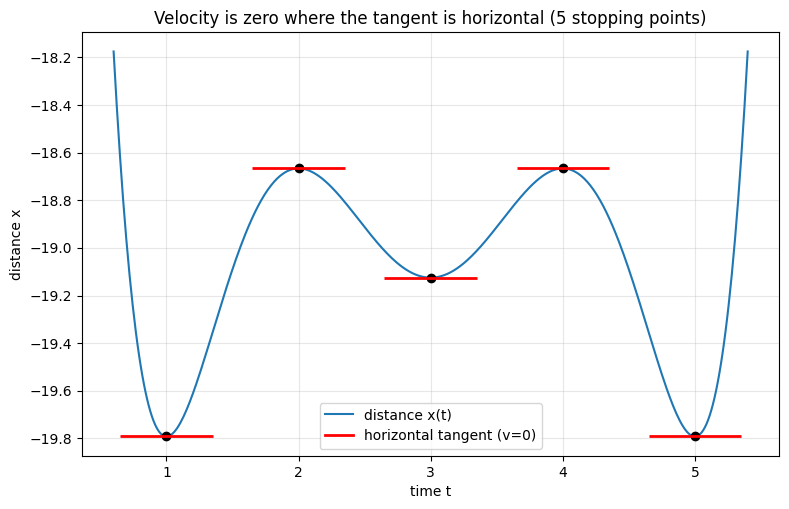

In [3]:
ts = np.linspace(0.6, 5.4, 400)
xs = x_n(ts)

plt.figure(figsize=(9, 5.5))
plt.plot(ts, xs, label="distance x(t)")
for s in stops:
    xst = x_n(s)
    plt.plot(s, xst, "ko")
    plt.hlines(xst, s-0.35, s+0.35, color="red", lw=2)   # horizontal tangent
plt.plot([], [], "red", lw=2, label="horizontal tangent (v=0)")
plt.title("Velocity is zero where the tangent is horizontal (5 stopping points)")
plt.xlabel("time t"); plt.ylabel("distance x")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. The farthest point is a stopping point

> *"At what time was the car farthest from its starting point? ... The point where the
> distance was the farthest is coincidentally one of the points where the car was stopped.
> This is no coincidence: if the car is moving, it could just go further."*

So the **maximum** distance occurs at a point where the **derivative is 0**.

In [4]:
dist_at_stops = {s: x_n(s) for s in stops}
farthest = max(dist_at_stops, key=dist_at_stops.get)
print("distance at each stopping point:")
for s, d in dist_at_stops.items():
    print(f"  t={s}: x={d:.3f}")
print(f"\nfarthest from start: t={farthest}, x={dist_at_stops[farthest]:.3f}")
print(f"velocity there: v({farthest}) = {v_n(farthest):.1f}  -> a zero-derivative point")

distance at each stopping point:
  t=1: x=-19.792
  t=2: x=-18.667
  t=3: x=-19.125
  t=4: x=-18.667
  t=5: x=-19.792

farthest from start: t=2, x=-18.667
velocity there: v(2) = -0.0  -> a zero-derivative point


## 5. The key property

> *"If you want to find the maximum or the minimum of a function, it occurs at one of the
> points where the derivative is 0 — where the tangent line is horizontal."*

$$
\boxed{\;\text{at a maximum or minimum: } \frac{dx}{dt} = 0.\;}
$$

These zero-derivative points are the **candidates** for maxima and minima. (Telling which is
which uses the second derivative — a later topic.) This single idea is the foundation of
**optimization**.

In [5]:
# the candidates for max/min are exactly where the derivative is zero
crit = sp.solve(sp.diff(x, t), t)        # solve x'(t) = v(t) = 0
print("critical points (x'(t) = 0):", crit)
print("these are the candidates for maxima and minima.")

critical points (x'(t) = 0): [1, 2, 3, 4, 5]
these are the candidates for maxima and minima.


## 6. Exercises

### Basic
1. What is the slope of a horizontal line, and what does it mean for velocity?
2. On a distance–time graph, how do you spot where the velocity is zero?

### Intermediate
3. For the trajectory above, list the times where the velocity is zero.
4. Which stopping point is the farthest from the start? Is its velocity zero?

### Advanced
5. For $f(x) = x^3 - 3x$, find the points where $f'(x) = 0$ (the candidates for max/min).
6. Explain why a maximum of a smooth function can't occur where the derivative is nonzero.

## 7. Solutions / Checks

In [6]:
x_s = sp.symbols('x')

# 3 & 4
print("3. velocity zero at t =", stops)
print(f"4. farthest at t={farthest} (x={dist_at_stops[farthest]:.3f}), velocity = {v_n(farthest):.1f}")

# 5.
f = x_s**3 - 3*x_s
print("5. f'(x)=0 at x =", sp.solve(sp.diff(f, x_s), x_s))

print("1. Slope 0 -> zero velocity (the object isn't moving).")
print("2. Where the tangent line is horizontal (slope 0).")
print("6. If f'>0 you can still increase by moving right, if f'<0 by moving left; only "
      "f'=0 leaves no direction that increases f -> a max (or min) needs a horizontal tangent.")

3. velocity zero at t = [1, 2, 3, 4, 5]
4. farthest at t=2 (x=-18.667), velocity = -0.0
5. f'(x)=0 at x = [-1, 1]
1. Slope 0 -> zero velocity (the object isn't moving).
2. Where the tangent line is horizontal (slope 0).
6. If f'>0 you can still increase by moving right, if f'<0 by moving left; only f'=0 leaves no direction that increases f -> a max (or min) needs a horizontal tangent.


## 8. Conclusion

- A **horizontal** line has slope $0$; on a distance–time graph that means **zero
  velocity** (stopped).
- The car's velocity is zero exactly where the **tangent is horizontal**.
- The **farthest** (maximum) point is always one of these zero-velocity points — no
  coincidence: if you were still moving, you could go further.
- Therefore a function's **maxima and minima occur where the derivative is 0**
  ($\frac{dx}{dt} = 0$, a horizontal tangent) — the cornerstone of optimization.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (5).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture on **slopes, maxima and minima**. Key spoken points, lightly
cleaned (the trajectory here is a representative one with the same five-stop structure):

> A property of the derivative: between $t=19$ and $t=20$ the distance is the same ($265$ at
> both), so the car didn't move — the line is horizontal with slope $0$. The slope is
> $\Delta x/\Delta t = (265-265)/1 = 0$ m/s. For a car that goes forward, stops, reverses,
> stops, and so on, the velocity is zero wherever the tangent is horizontal (slope 0) — the
> points where it was stopped; there are five such points. The car is farthest from its
> start at the highest distance, and that point coincides with a stopping point — no
> coincidence, because if it were still moving it could go further. So to find a maximum or
> minimum of a function, look where the derivative is 0, i.e. where the tangent line is
> horizontal.